In [2]:
# --- Read all data -----------------------------------------------------------

from pathlib import Path
import pandas as pd

# Folder containing your CSVs
folder = Path('./data')

# Dictionary: {filename_without_ext: DataFrame}
data = {
    csv.stem: pd.read_csv(csv)
    for csv in folder.glob('*.csv')
}

In [3]:
# --- Examine the data --------------------------------------------------------
do_display = False
for name, df in data.items():
    print(f"{name:>35} {df.shape}")
    if do_display:
        display(df)

                   Exam Pairs ABW-2 (64, 65)
                         Exam pairs (20, 21)
                         exam_days3 (34, 2)
   M24 exam names and block lengths (64, 4)
                      Toy exam list (20, 4)


In [4]:
# --- Imports --------------------------------------------------------------------------

# Standard library
import numpy as np

# IPython autoreload (only works in notebooks)
%load_ext autoreload
%autoreload 2

# Local modules
import src.ib_graphics as g
import src.data_utils as d


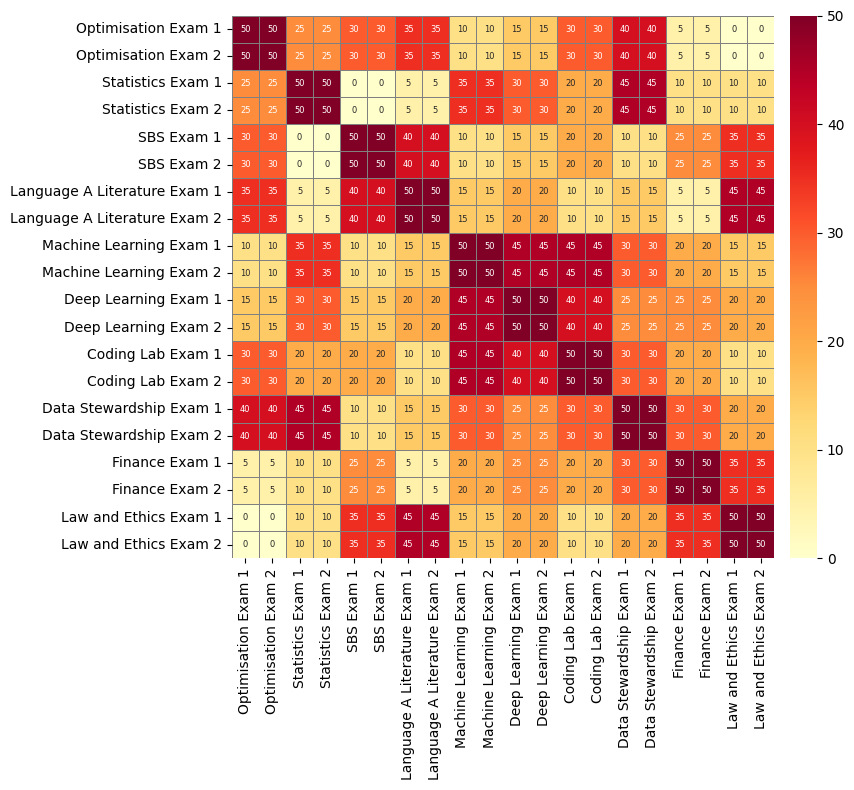

In [11]:
g.plot_exam_matrix( d.prepare_pairs_matrix( data['Exam pairs'] ), figsize=(10,8) )

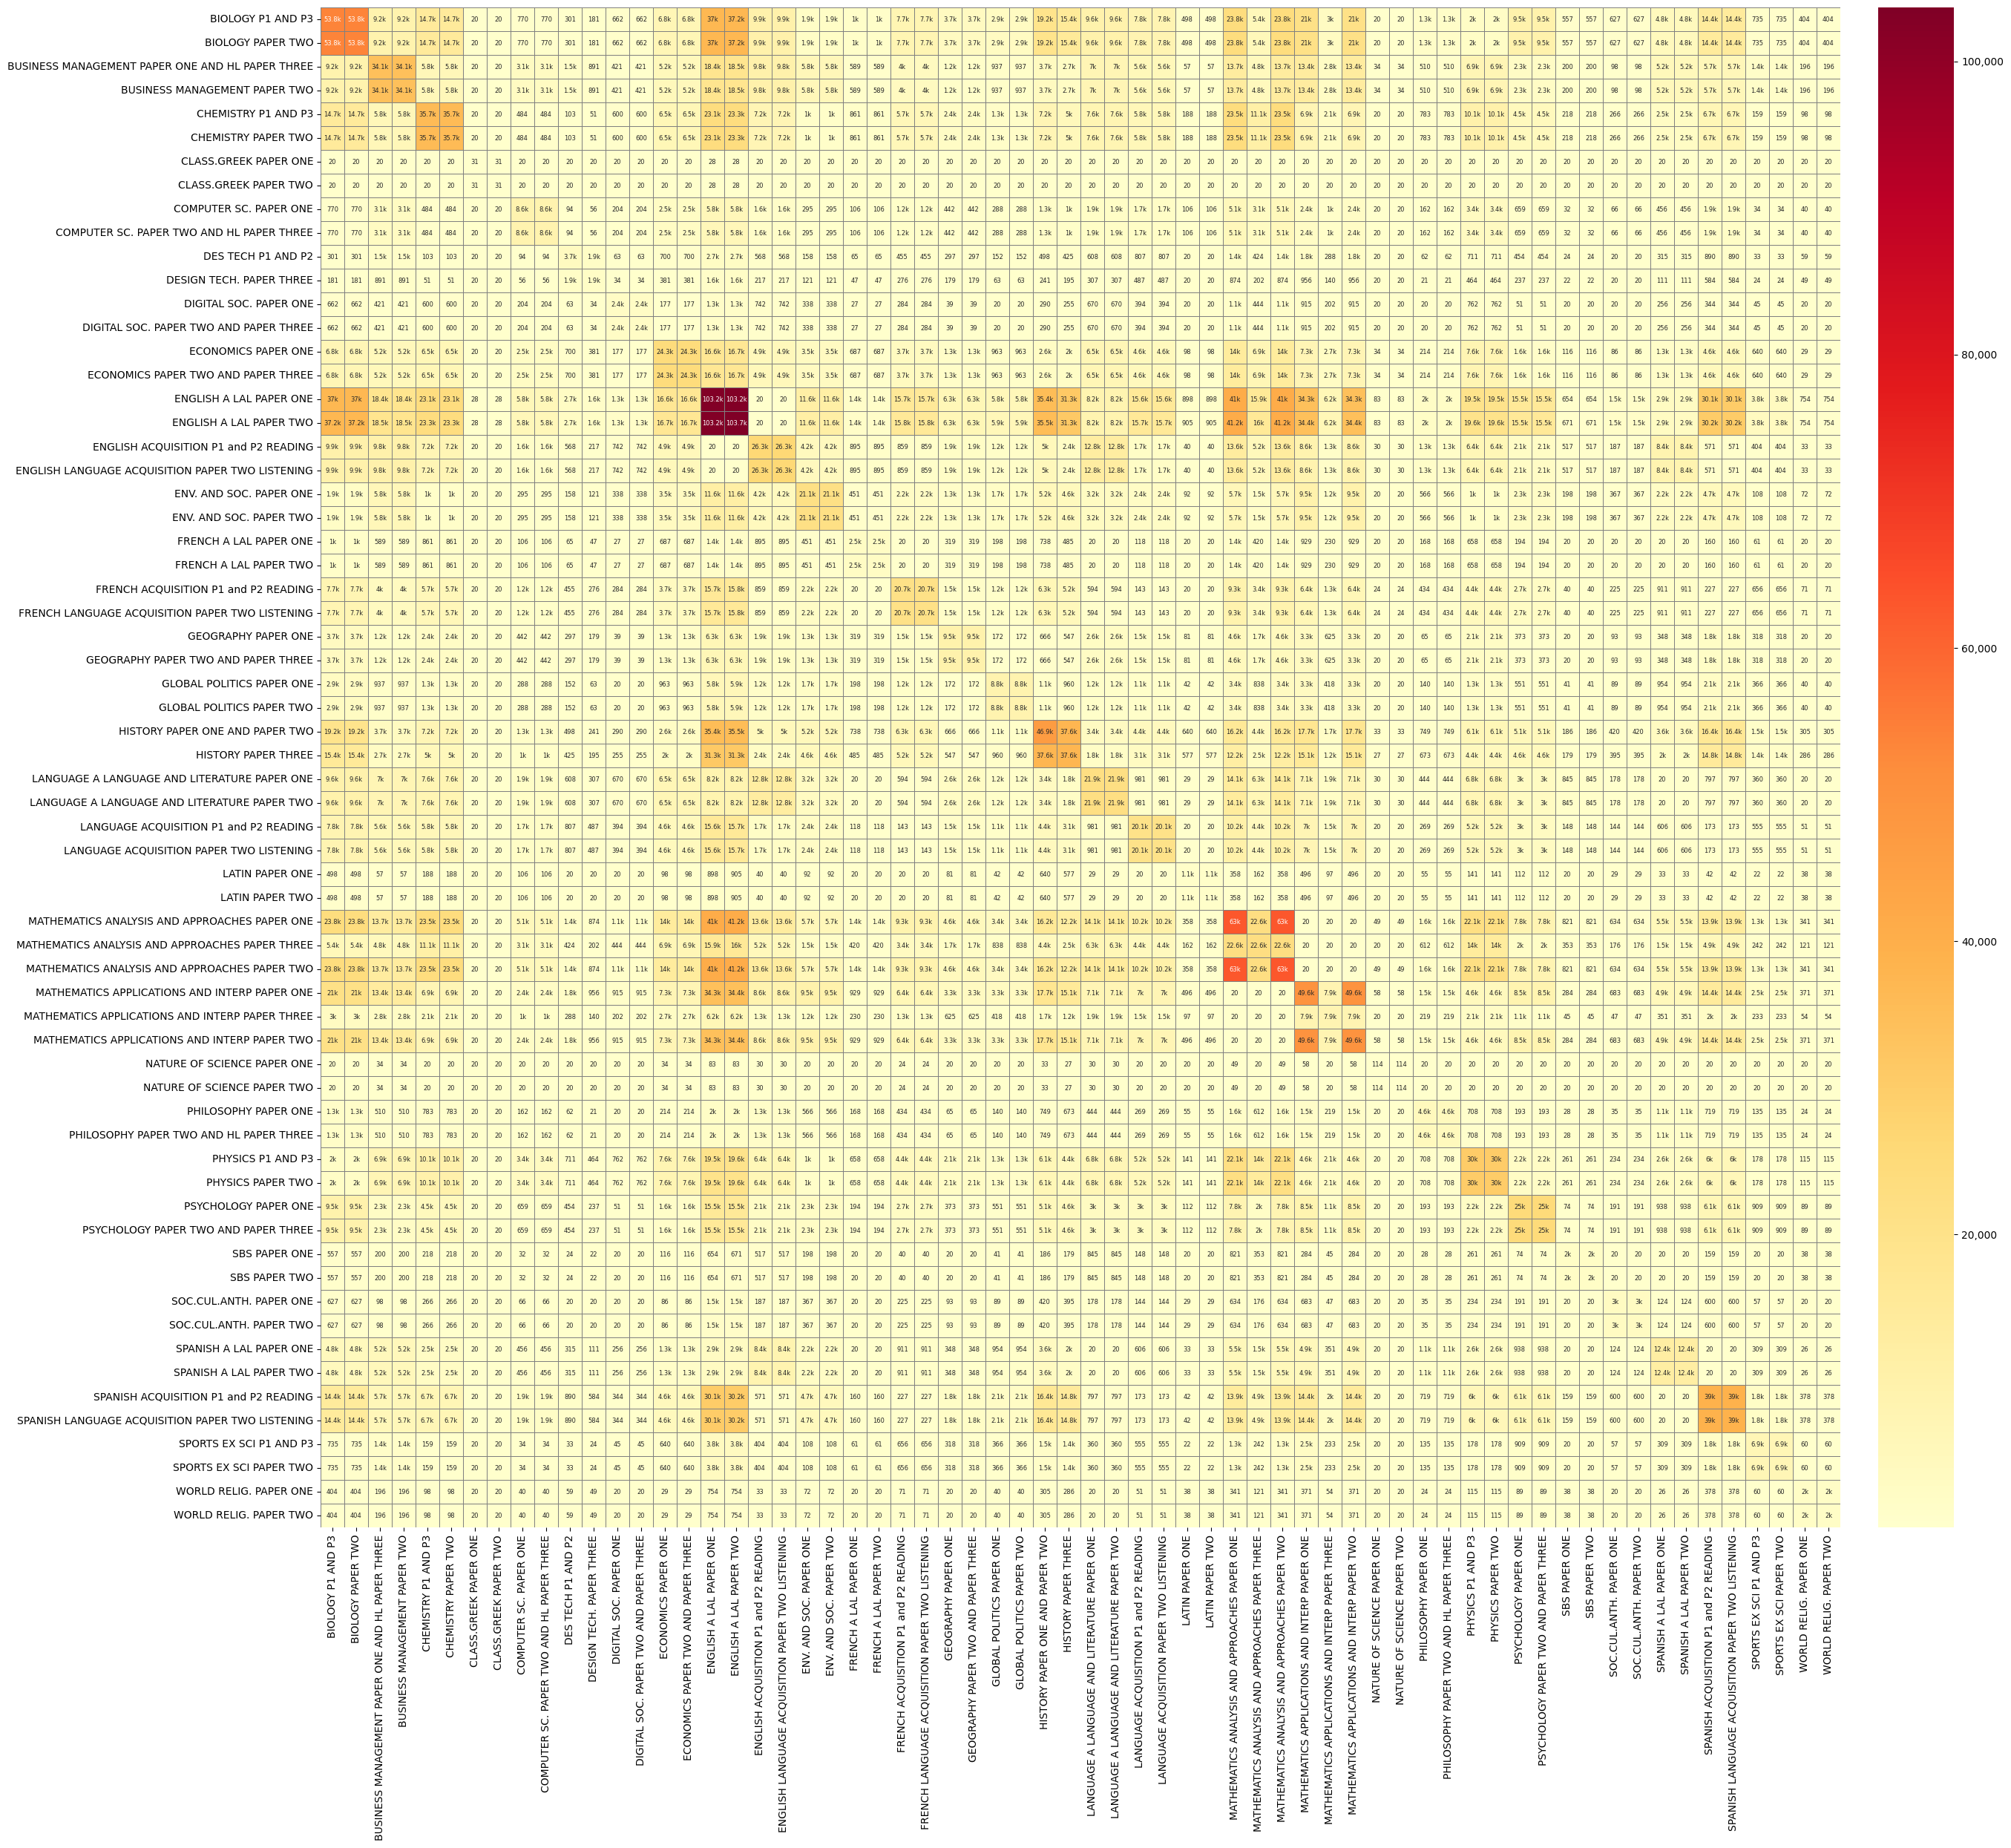

In [6]:
# --- Preprocess and vizualize the data ---------------------------------------

pairs = d.prepare_pairs_matrix( data['Exam Pairs ABW-2'] )
assert set(pairs.index) == set(pairs.columns)
g.plot_exam_matrix( pairs, figsize=(30,25) )

[<Figure size 1440x720 with 1 Axes>, <Figure size 1440x720 with 1 Axes>]

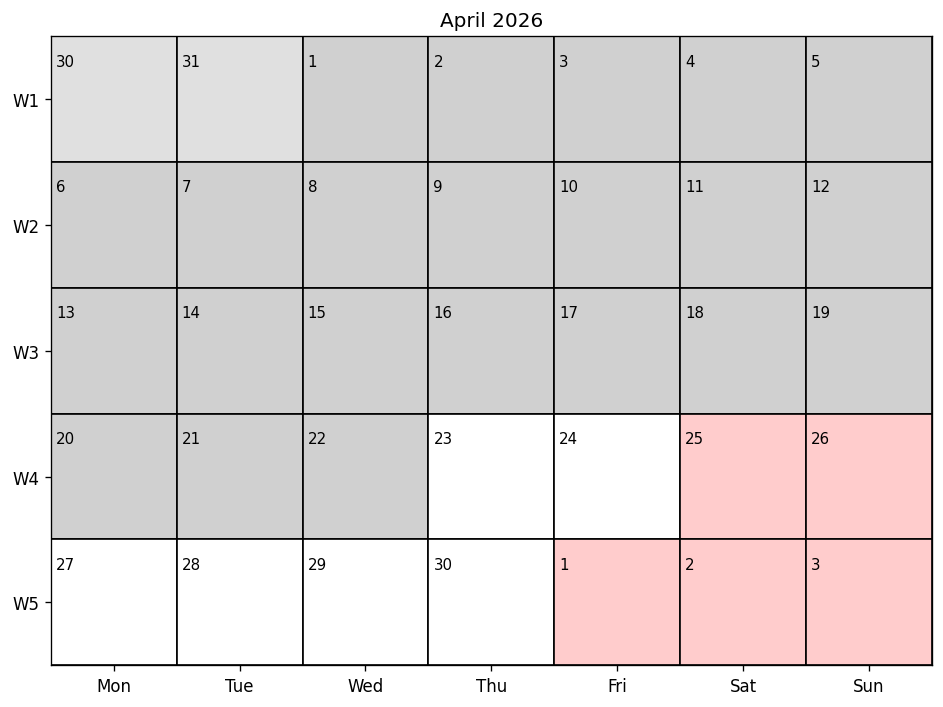

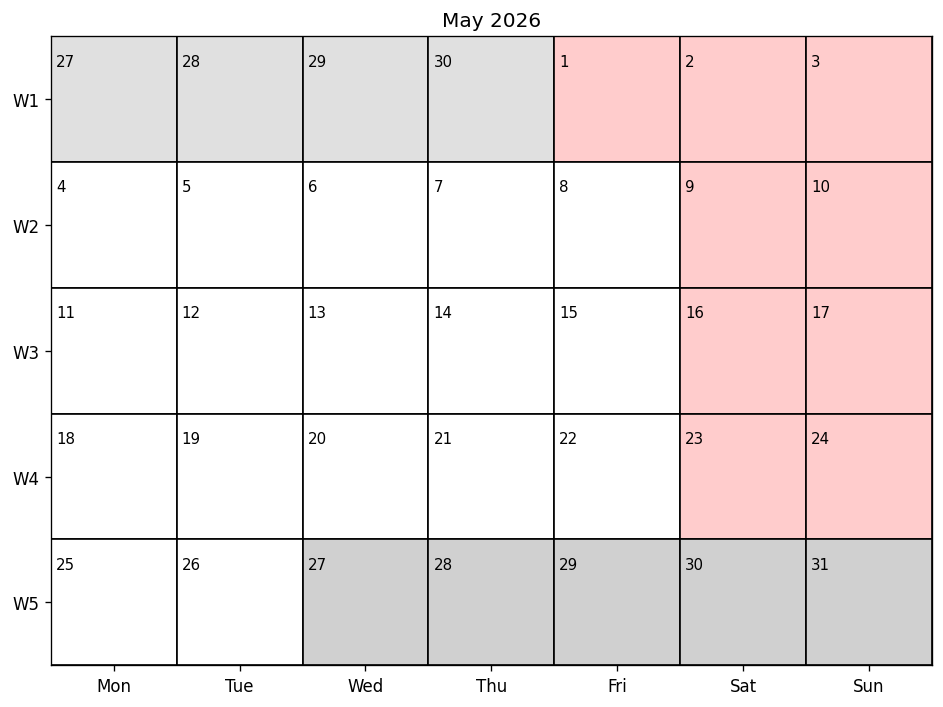

In [7]:
# --- Preprocess and vizualize the data ---------------------------------------

days = d.prepare_exam_days( data['exam_days3'] )
assert len(d.find_dow_mismatches(days)) == 0

free_days = days[days.DOW.isin({'Sat', 'Sun'})].Date.to_list()
# Add May 1st for all years in the data
years = days[days.Date.dt.month == 5].Date.dt.year.unique()
for y in years:
    free_days.append(pd.Timestamp(year=y, month=5, day=1))

g.plot_month_calendar( days, free_days=free_days )

In [8]:
# --- Preprocess and vizualize the data ---------------------------------------

examlist = d.prepare_exam_list( data['M24 exam names and block lengths'] )
assert set(examlist['FULL_NAME']) <= set(pairs.index)
examlist

,Subject,FULL_NAME,Length,Length_hm
1,LANGUAGE A LITERATURE,LANGUAGE A LANGUAGE AND LITERATURE PAPER ONE,135,2:15
2,LANGUAGE A LITERATURE,LANGUAGE A LANGUAGE AND LITERATURE PAPER TWO,105,1:45
3,LANGUAGE ACQUISITION,LANGUAGE ACQUISITION P1 and P2 READING,150,2:30
4,LANGUAGE ACQUISITION,LANGUAGE ACQUISITION PAPER TWO LISTENING,60,1:00
5,SBS,SBS PAPER ONE,90,1:30
...,...,...,...,...
60,SPANISH LANGUAGE ACQUISITION,SPANISH LANGUAGE ACQUISITION PAPER TWO LISTENING,60,1:00
61,SPORTS EX SCI,SPORTS EX SCI P1 AND P3,135,2:15
62,SPORTS EX SCI,SPORTS EX SCI PAPER TWO,135,2:15
63,WORLD RELIG.,WORLD RELIG. PAPER ONE,75,1:15
